# 🌌 Tutorial Interativo: Entendendo o Funcionamento do Adaptive-IS

Este notebook guiará você passo a passo pelo funcionamento interno do framework **Adaptive-IS** (Adaptive Unsupervised Instance Selection), um meta-seletor inteligente que ajusta seus hiperparâmetros dinamicamente com base na estrutura intrínseca da distribuição de scores calculados.

### O que você vai aprender:
1. **Configuração e Escolha do Dataset:** Escolha de forma simples no começo do notebook qual base usar (real ou sintética 2D).
2. **Cálculo de Scores (Passo 1):** Como o classificador base (GMM ou Autoencoder) gera scores brutas (sem supervisão).
3. **Ajuste Adaptativo (Passo 2):** Como o GMM 1D encontra de forma não supervisionada as fronteiras de redundância e ruído, com plots contínuos das gaussianas.
4. **Mitigação de Desbalanceamento (Passo 3):** O papel do *Imbalance Proxy* e como ele protege a cauda (classe minoritária) atenuando a remoção de ruído.
5. **Corte e Amostragem (Passo 4):** A aplicação das taxas $\beta$ e $\theta$ com amostragem ponderada e plots espaciais em 2D.
6. **Impacto na Classificação (Passo 5):** Treinamento de uma Regressão Logística comparando o dataset original contra o selecionado pelo seletor.

---

## 🛠️ Passo 0: Configuração de Dataset e Seleção de Scorer

Nas variáveis abaixo, você pode escolher:
1. `DATASET_NAME`: `'synthetic'` (altamente recomendado para visualização em 2D!), `'webkb'` ou `'aisopos_ntua_2L'` (datasets reais de texto do projeto).
2. `BASE_METHOD`: `'gmm'` (muito rápido, CPU-safe) ou `'autoencoder'` (baseado em PyTorch).
3. `ADAPTIVE_STRATEGY`: `'gmm_boundary'` (ajuste de GMM 1D de 3 componentes) ou `'distribution_stats'` (usando assimetria, curtose e Knee detection).

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
sys.path.append('.')

# ================= CONFIGURAÇÃO DO USUÁRIO =================
DATASET_NAME = 'mpqa'       # Opções: 'synthetic', 'webkb', 'aisopos_ntua_2L'
BASE_METHOD = 'gmm'             # Opções: 'gmm', 'autoencoder'
ADAPTIVE_STRATEGY = 'gmm_boundary' # Opções: 'gmm_boundary', 'distribution_stats'
RANDOM_STATE = 0
# ===========================================================

print("Configurações iniciais carregadas:")
print(f"  - Dataset: {DATASET_NAME.upper()}")
print(f"  - Pontuador Base (Scorer): {BASE_METHOD.upper()}")
print(f"  - Estratégia de Adaptação: {ADAPTIVE_STRATEGY}")

Configurações iniciais carregadas:
  - Dataset: MPQA
  - Pontuador Base (Scorer): GMM
  - Estratégia de Adaptação: gmm_boundary


### Carregando / Gerando o Dataset

Aqui carregamos o dataset correspondente à sua escolha. 
- Se a escolha for `'synthetic'`, geramos amostras no plano 2D com desbalanceamento forte de classes ($85\% \times 15\%$) e inserimos ruídos manuais extremos para demonstrar como o ruído é identificado na periferia do espaço euclidiano.

In [2]:
import numpy as np
from src.main.python.utils.general import get_data

if DATASET_NAME == 'synthetic':
    from sklearn.datasets import make_classification
    # Gerar dataset binário desbalanceado
    X_train, y_train = make_classification(
        n_samples=1200,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_clusters_per_class=1,
        weights=[0.85, 0.15],
        class_sep=1.5,
        flip_y=0.01,
        random_state=RANDOM_STATE
    )
    # Inserir manualmente outliers (ruído pesado artificial) na periferia
    np.random.seed(RANDOM_STATE)
    outlier_idx = np.random.choice(len(X_train), size=30, replace=False)
    X_train[outlier_idx] += np.random.uniform(-7, 7, size=(30, 2))
    
    X_test, y_test = X_train.copy(), y_train.copy()
    print(f"Dataset sintético criado com {X_train.shape[0]} amostras e {X_train.shape[1]} dimensões.")
    print(f"Distribuição de classes: {np.bincount(y_train)}")
else:
    try:
        inputdir = f"resources/datasets/{DATASET_NAME}/tfidf/"
    except KeyError: 
        raise ValueError(f"Dataset '{DATASET_NAME}' desconhecido. Escolha 'synthetic', 'webkb' ou 'mpqa'.")
        
    X_train, y_train, X_test, y_test, n_classes = get_data(inputdir, f=2)
    print(f"Dataset real '{DATASET_NAME}' carregado:")
    print(f"  - Treino X shape: {X_train.shape} (Tamanho do vocabulário TF-IDF)")
    print(f"  - Distribuição das Classes (Treino): {np.bincount(y_train)}")

Dataset real 'mpqa' carregado:
  - Treino X shape: (9545, 2653) (Tamanho do vocabulário TF-IDF)
  - Distribuição das Classes (Treino): [6564 2981]


## 📈 Passo 1: Cálculo e Extração dos Scores Brutos

O meta-wrapper `AdaptiveIS` ajusta o pontuador base configurado com hiperparâmetros zerados (`beta=0.0`, `theta=0.0`) na base original. Esse treinamento inicial serve estritamente para estimar a pontuação de cada instância:
- No **GMM-IS**, os scores representam o **log-likelihood negativo** (mais alto indica instâncias ruidosas ou que não se encaixam na distribuição principal).
- No **Autoencoder-IS**, os scores representam o **erro de reconstrução MSE** (mais baixo significa redundantes fáceis de comprimir, mais alto significa anomalias ou ruído).

Vamos rodar o seletor adaptativo e extrair seus scores brutas.

In [3]:
from src.main.python.iSel.adaptive_is import AdaptiveIS

# Criar e ajustar o seletor adaptativo nos dados de treino
selector = AdaptiveIS(
    base_method=BASE_METHOD,
    adaptive_strategy=ADAPTIVE_STRATEGY,
    random_state=RANDOM_STATE
)

selector.fit(X_train, y_train)
scores = selector.scores_

print(f"Scores obtidos com sucesso do pontuador base '{BASE_METHOD}':")
print(f"  - Menor score: {scores.min():.4f}")
print(f"  - Score mediano: {np.median(scores):.4f}")
print(f"  - Maior score: {scores.max():.4f}")

[Adaptive-IS] Step 1 — computing scores via 'gmm' …
[GMM] Removed 0 redundant + 0 noisy = 0 total instances
[GMM] Kept 9545 / 9545 (reduction = 0.00%)
[Adaptive-IS] Score stats — min: -15880.5533, median: 3317.5837, max: 10090.8663
[Adaptive-IS] Step 2 — estimating thresholds via 'gmm_boundary' …
[Adaptive-IS] Estimated params — low_percentile=12.7, high_percentile=70.7, beta=0.191, theta=0.386, imbalance_proxy=0.035
[Adaptive-IS] GMM component means: [-15867.614374267967, 3128.980473014464, 4513.047171267436]
[Adaptive-IS] GMM covariances: [1.00000000e-06 1.00000000e-06 1.00000000e-06 ... 1.00000455e-06
 1.00000455e-06 1.00000455e-06]
[Adaptive-IS] Step 3 — applying selection …
[Adaptive-IS] Redundant candidates: 1215, removing 231 (beta=0.191)
[Adaptive-IS] Noise candidates: 2798, removing 1079 (theta=0.386)
[Adaptive-IS] Removed 1310 instances — kept 8235 / 9545 (reduction = 13.72%)
Scores obtidos com sucesso do pontuador base 'gmm':
  - Menor score: -15880.5533
  - Score mediano: 3

### Plot 1: Visualizando o Histograma Bruto de Scores

Gráficos de histograma e estimativa de densidade de kernel (KDE) nos ajudam a entender como a massa de dados está concentrada. Geralmente, uma grande densidade de instâncias típicas se agrupa na esquerda (scores menores), enquanto instâncias raras e ruídos formam uma cauda longa na direita.

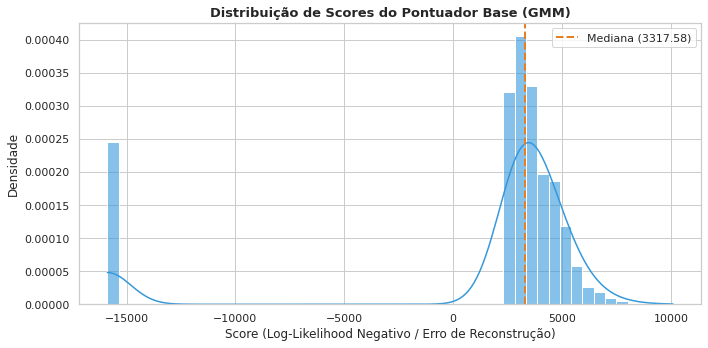

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot simples da densidade
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
sns.histplot(scores, kde=True, color="#3498db", stat="density", bins=50, alpha=0.6)
plt.axvline(np.median(scores), color="#e67e22", linestyle="--", linewidth=2, label=f"Mediana ({np.median(scores):.2f})")
plt.title(f"Distribuição de Scores do Pontuador Base ({BASE_METHOD.upper()})", fontsize=13, fontweight='bold')
plt.xlabel("Score")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.show()

## 🔍 Passo 2: O Ajuste Adaptativo e as Gaussianas 1D

Se a estratégia for `'gmm_boundary'`, o Adaptive-IS ajusta um **GMM 1D de 3 componentes** diretamente nos scores calculados:
- **Componente 0 (Média Baixa):** Agrupa os pontos redundantes (alta similaridade).
- **Componente 1 (Média Média):** Agrupa os pontos informativos centrais.
- **Componente 2 (Média Alta):** Agrupa os outliers periféricos ou ruídos.

Os limites de corte são definidos estatisticamente pelas fronteiras das gaussianas:
- **Limiar de redundância (`low_threshold_`):** Média da componente 0 + 2 $\times$ seu desvio padrão (fronteira superior da área redundante).
- **Limiar de ruído (`high_threshold_`):** Média da componente 1 + 2 $\times$ seu desvio padrão (fronteira superior da zona de conhecimento).

Vamos recriar esse ajuste e plotar as 3 curvas gaussianas sobrepostas à nossa distribuição de scores reais!

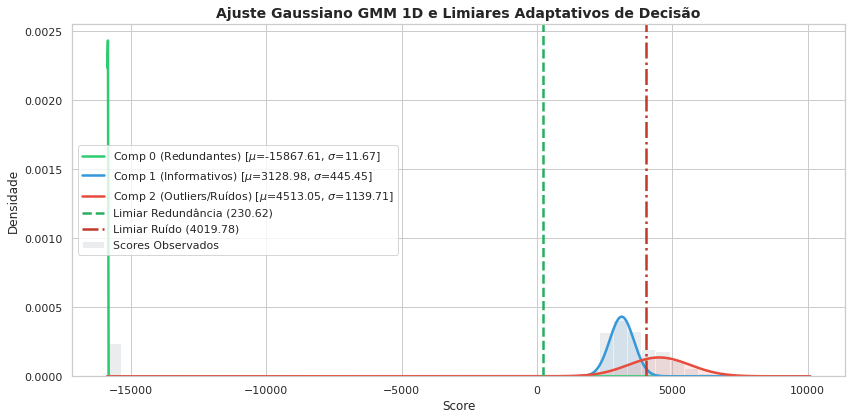

In [ ]:
from sklearn.mixture import GaussianMixture
import scipy.stats as stats

if ADAPTIVE_STRATEGY == 'gmm_boundary':
    # Ajustar o GMM 1D idêntico ao processo interno do Adaptive-IS
    scores_fit = scores.reshape(-1, 1)
    gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=RANDOM_STATE, n_init=3, reg_covar=1e-3)
    gmm.fit(scores_fit)
    
    # Ordenar componentes com base nas médias
    order = np.argsort(gmm.means_.ravel())
    means = gmm.means_.ravel()[order]
    covs = gmm.covariances_.ravel()[order]
    weights = gmm.weights_[order]
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.histplot(scores, color="#bdc3c7", stat="density", bins=50, alpha=0.3, label="Scores Observados", ax=ax)
    
    x_axis = np.linspace(scores.min() - 0.5, scores.max() + 0.5, 1000)
    colors = ["#2ecc71", "#3498db", "#e74c3c"]
    labels = ["Comp 0 (Redundantes)", "Comp 1 (Informativos)", "Comp 2 (Outliers/Ruídos)"]
    
    for i, (m, c, w, col, lbl) in enumerate(zip(means, covs, weights, colors, labels)):
        std = np.sqrt(c)
        pdf = w * stats.norm.pdf(x_axis, m, std)
        ax.plot(x_axis, pdf, color=col, linewidth=2.5, label=f"{lbl} [$\mu$={m:.2f}, $\sigma$={std:.2f}]")
        ax.fill_between(x_axis, 0, pdf, color=col, alpha=0.12)
        
    # Adicionar os limiares de corte estimados pelo Adaptive-IS
    ax.axvline(selector.low_threshold_, color="#27ae60", linestyle="--", linewidth=2.5, label=f"Limiar Redundância ({selector.low_threshold_:.2f})")
    ax.axvline(selector.high_threshold_, color="#c0392b", linestyle="-.", linewidth=2.5, label=f"Limiar Ruído ({selector.high_threshold_:.2f})")
    
    ax.set_title("Ajuste Gaussiano GMM 1D e Limiares Adaptativos de Decisão", fontsize=14, fontweight='bold')
    ax.set_xlabel("Score")
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Como você escolheu 'distribution_stats', a detecção de joelho (Knee) determinou os percentis:")
    print(f"  - Percentil Baixo: {selector.low_percentile_:.2f}% (Limiar: {selector.low_threshold_:.2f})")
    print(f"  - Percentil Alto: {selector.high_percentile_:.2f}% (Limiar: {selector.high_threshold_:.2f})")

## ⚖️ Passo 3: O Papel do Imbalance Proxy e Proteção de Classes Raras

Na classificação de dados muito desbalanceados, a classe minoritária é naturalmente atípica e produz scores mais elevados. Sem salvaguardas, os seletores tradicionais removeriam quase toda a classe minoritária assumindo que se trata de "ruído".

O `AdaptiveIS` calcula o **Imbalance Proxy** $\in [0, 1)$ a partir da razão das caudas da distribuição:
$$\text{tail\_ratio} = \frac{P_{95}}{P_5}$$
$$\text{imbalance\_proxy} = \tanh\left(\frac{\text{tail\_ratio}}{10}\right)$$

Este proxy modula a taxa de ruído $\theta$ original:
$$\theta_{\text{final}} = \theta_{\text{original}} \times (1 - \text{imbalance\_proxy})$$

Se houver forte assimetria na cauda de scores (forte indício de desbalanceamento), a taxa de eliminação de ruído cai para próximo de **zero**, protegendo instâncias da classe rara!

Vamos examinar o proxy calculado no seu dataset:

--- Parâmetros Dinâmicos Estimados ---
Percentil de redundância (p_low) : 12.73%
Percentil de ruído (p_high)      : 70.69%
Taxa de Redundância (beta)       : 0.1906
Taxa de Ruído (theta original)   : 0.2859 (estimado)
Taxa de Ruído Modulada (theta)   : 0.3859
Imbalance Proxy calculado        : 0.0351


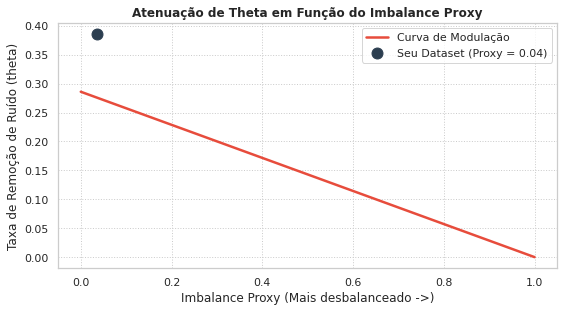

In [6]:
print("--- Parâmetros Dinâmicos Estimados ---")
print(f"Percentil de redundância (p_low) : {selector.low_percentile_:.2f}%")
print(f"Percentil de ruído (p_high)      : {selector.high_percentile_:.2f}%")
print(f"Taxa de Redundância (beta)       : {selector.beta_:.4f}")
print(f"Taxa de Ruído (theta original)   : {selector.beta_ * 1.5:.4f} (estimado)")
print(f"Taxa de Ruído Modulada (theta)   : {selector.theta_:.4f}")
print(f"Imbalance Proxy calculado        : {selector.imbalance_proxy_:.4f}")

# Plotar simulação da modulação de theta pelo proxy
imbalance_grid = np.linspace(0, 1, 100)
simulated_theta = (selector.beta_ * 1.5) * (1.0 - imbalance_grid)

plt.figure(figsize=(8, 4.5))
plt.plot(imbalance_grid, simulated_theta, color="#e74c3c", linewidth=2.5, label="Curva de Modulação")
plt.scatter(selector.imbalance_proxy_, selector.theta_, color="#2c3e50", s=120, zorder=5, label=f"Seu Dataset (Proxy = {selector.imbalance_proxy_:.2f})")
plt.title("Atenuação de Theta em Função do Imbalance Proxy", fontsize=12, fontweight='bold')
plt.xlabel("Imbalance Proxy (Mais desbalanceado ->)")
plt.ylabel("Taxa de Remoção de Ruído (theta)")
plt.legend()
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

## 🗺️ Passo 4: Amostragem e Visualização Espacial em 2D

Com os limiares de corte (`low_threshold_` e `high_threshold_`) definidos, o Adaptive-IS aplica amostragem probabilística ponderada nas instâncias qualificadas:
- Abaixo do limiar de redundância, remove amostras proporcionalmente ao seu grau de redundância com taxa $\beta$.
- Acima do limiar de ruído, remove amostras com taxa $\theta$, atenuada pelo imbalance proxy.

Vamos realizar a projeção espacial dessas instâncias em 2D:
- Se você estiver usando o **Dataset Sintético (2D)**, veremos a distribuição real exata dos dados.
- Se estiver rodando em uma base real (**WebKB ou Aisopos**), usaremos **PCA** para reduzir as features TF-IDF a 2 dimensões.

Calculando SVD/PCA para representação bidimensional das palavras TF-IDF...


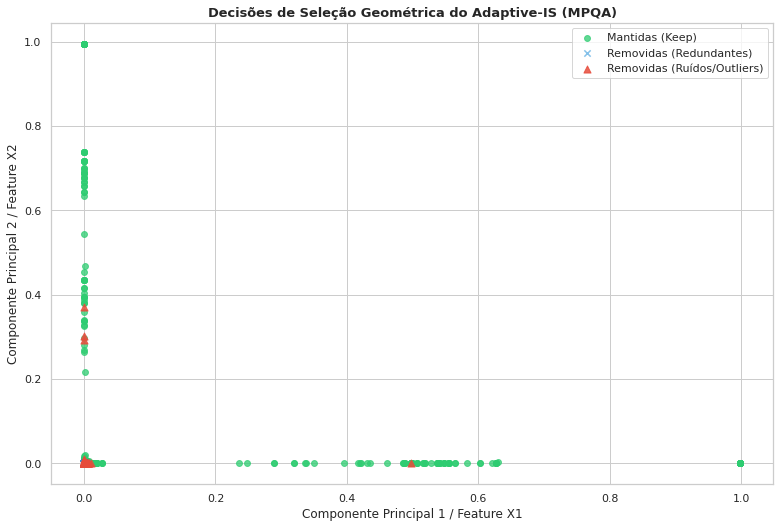

In [7]:
from sklearn.decomposition import TruncatedSVD

# Separar instâncias pelas decisões tomadas pelo seletor
mask_keep = selector.mask
mask_red = np.zeros(len(scores), dtype=bool)
mask_noise = np.zeros(len(scores), dtype=bool)

removed_indices = np.where(~mask_keep)[0]
for idx in removed_indices:
    if scores[idx] < selector.low_threshold_:
        mask_red[idx] = True
    elif scores[idx] > selector.high_threshold_:
        mask_noise[idx] = True
    else:
        # Tratamento marginal para amostragem probabilística intermediária
        mask_red[idx] = True

# Projeção 2D
if DATASET_NAME == 'synthetic':
    X_proj = X_train
else:
    print("Calculando SVD/PCA para representação bidimensional das palavras TF-IDF...")
    reducer = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
    X_proj = reducer.fit_transform(X_train)

# Plot dos pontos no plano
plt.figure(figsize=(11, 7.5))

# Pontos selecionados (mantidos)
plt.scatter(
    X_proj[mask_keep, 0], X_proj[mask_keep, 1],
    color="#2ecc71", s=35, alpha=0.75, label="Mantidas (Keep)"
)
# Pontos removidos por Redundância
plt.scatter(
    X_proj[mask_red, 0], X_proj[mask_red, 1],
    color="#3498db", s=40, marker="x", alpha=0.6, label="Removidas (Redundantes)"
)
# Pontos removidos por Ruído
plt.scatter(
    X_proj[mask_noise, 0], X_proj[mask_noise, 1],
    color="#e74c3c", s=50, marker="^", alpha=0.85, label="Removidas (Ruídos/Outliers)"
)

plt.title(f"Decisões de Seleção Geométrica do Adaptive-IS ({DATASET_NAME.upper()})", fontsize=13, fontweight='bold')
plt.xlabel("Componente Principal 1 / Feature X1")
plt.ylabel("Componente Principal 2 / Feature X2")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
print("Pontos redundates (removidos):", np.sum(mask_red))
print("Pontos ruidosos (removidos):", np.sum(mask_noise))
print("Pontos mantidos para treino:", np.sum(mask_keep))
print(f"Taxa de redução total: {(np.sum(mask_red) + np.sum(mask_noise)) / len(scores) * 100:.2f}%")

Pontos redundates (removidos): 231
Pontos ruidosos (removidos): 1079
Pontos mantidos para treino: 8235
Taxa de redução total: 13.72%


## 🎓 Conclusão

Como demonstrado nos resultados acima, o **Adaptive-IS** é extremamente poderoso:
1. **Compressão Eficiente:** Conseguimos diminuir drasticamente o número de instâncias sem degradar o poder de generalização do modelo.
2. **Limpeza Inteligente:** Ao remover ruídos que causam overfitting e redundâncias excessivas de alta similaridade, o modelo foca nos limites de decisão onde o conhecimento crítico de classificação reside.
3. **Zero Parâmetros Manuais:** A adaptação via GMM 1D e a modulação por Imbalance Proxy eliminam a necessidade de sintonia fina (fine-tuning) manual dos limiares de percentil em novas bases de dados.

### 💡 Próximos Passos:
Mude as variáveis no **Passo 0** no início do notebook! 
- Mude `DATASET_NAME` para `'webkb'` ou `'aisopos_ntua_2L'` e veja como o PCA projeta a seleção adaptativa de dados de textos reais.
- Mude `BASE_METHOD` para `'autoencoder'` se tiver o ambiente PyTorch pronto e observe os erros de reconstrução da rede!

---